# SG-CancerSight — Phase 1: Data Management & Wrangling
## NCCS Data Analyst (DDOIT) Portfolio Project

**Author:** Dr. Lakshmi C. | PhD Mathematics | Healthcare Operations Research  
**Dataset:** SEER Breast Cancer Registry (4,024 patients, 15 clinical variables)  
**JD Requirement Covered:** Data Management & Wrangling (Section 1 of NCCS Job Description)

---

### What this notebook covers
| Step | Task | JD Requirement |
|------|------|---------------|
| 1 | Load raw dataset & initial profiling | *Access and extract large-scale datasets* |
| 2 | Missing value analysis | *Data quality checks and validation* |
| 3 | Identify & document data quality issues | *Sensitivity analyses* |
| 4 | Clean: remove invalids, recode sentinels | *Clean and manage datasets* |
| 5 | Impute missing values (documented) | *Harmonise data from multiple sources* |
| 6 | Create derived analysis variables | *Develop reproducible analytical workflows* |
| 7 | Build data dictionary | *Maintain clear documentation* |
| 8 | Save clean dataset | *Well-documented analytical workflows* |
| 9 | Run automated quality tests | *Data quality checks and validation* |
| 10 | Exploratory Data Analysis (EDA) | *Descriptive analyses* |

---
> **Data governance note:** This project uses a synthetic research replica of the SEER registry structure.  
> In a real NCCS deployment, all data handling would comply with Singapore PDPA, MOH Data Governance Framework, and DSRB approval protocols.


## Step 0 — Import libraries & configure paths

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import json
import logging
import warnings
from pathlib import Path
from datetime import datetime

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Display settings ───────────────────────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# ── Project paths ──────────────────────────────────────────────────────────
BASE_DIR   = Path().resolve().parent          # root of sg-cancersight/
RAW_PATH   = BASE_DIR / 'data' / 'raw'  / 'seer_raw.csv'
CLEAN_PATH = BASE_DIR / 'data' / 'processed' / 'seer_clean.csv'
DICT_PATH  = BASE_DIR / 'data' / 'processed' / 'data_dictionary.json'
FIG_DIR    = BASE_DIR / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"Base directory : {BASE_DIR}")
print(f"Raw data       : {RAW_PATH}")
print(f"Output figures : {FIG_DIR}")


Base directory : /home/claude/sg-cancersight
Raw data       : /home/claude/sg-cancersight/data/raw/seer_raw.csv
Output figures : /home/claude/sg-cancersight/outputs/figures


## Step 1 — Load raw dataset

We load the raw CSV **without any modifications** and immediately inspect its structure.  
The raw file is never overwritten — all changes go to `data/processed/`.


In [2]:
df_raw = pd.read_csv(RAW_PATH)

print(f"Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"\nColumns:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:>2}. {col}")


Shape: 4,024 rows × 15 columns

Columns:
   1. Age
   2. Race
   3. Marital Status
   4. T Stage
   5. N Stage
   6. 6th Stage
   7. Grade
   8. A Stage
   9. Tumor Size
  10. Regional Node Examined
  11. Reginol Node Positive
  12. Estrogen Status
  13. Progesterone Status
  14. Survival Months
  15. Status


In [3]:
# First 5 rows
df_raw.head()


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Regional Node Examined,Reginol Node Positive,Estrogen Status,Progesterone Status,Survival Months,Status
0,51,White,Divorced,T1,N0,I,3 Poorly differentiated,Regional,13.00,7.00,0,Negative,Negative,91,Alive
1,80,Black,Married,T4,N0,IIIC,anaplastic; Grade IV,Regional,129.00,7.00,0,Positive,Positive,67,Alive
2,65,White,Married,T1,N0,I,anaplastic; Grade IV,Regional,4.00,2.00,0,Positive,Positive,70,Alive
3,59,White,Married,T3,N2,IIIB,3 Poorly differentiated,Regional,58.00,14.00,4,Positive,Negative,73,Alive
4,42,White,Widowed,T1,N1,IIA,3 Poorly differentiated,Regional,18.00,16.00,2,Negative,Negative,72,Alive


In [4]:
# Data types and non-null counts
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4024 non-null   int64  
 1   Race                    4024 non-null   object 
 2   Marital Status          4024 non-null   object 
 3   T Stage                 4024 non-null   object 
 4   N Stage                 4024 non-null   object 
 5   6th Stage               4024 non-null   object 
 6   Grade                   3897 non-null   object 
 7   A Stage                 4024 non-null   object 
 8   Tumor Size              3897 non-null   float64
 9   Regional Node Examined  3898 non-null   float64
 10  Reginol Node Positive   4024 non-null   int64  
 11  Estrogen Status         4024 non-null   object 
 12  Progesterone Status     4024 non-null   object 
 13  Survival Months         4024 non-null   int64  
 14  Status                  4024 non-null   

In [5]:
# Descriptive statistics — numeric columns
df_raw.describe().round(2)


,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.00,3897.00,3898.00,4024.00,4024.00
mean,55.76,31.69,15.16,2.29,77.91
std,14.13,37.93,8.32,4.10,21.91
min,0.00,1.00,1.00,0.00,-1.00
25%,46.00,11.00,8.00,0.00,63.00
50%,55.00,23.00,15.00,0.00,79.00
75%,66.00,44.00,23.00,3.00,96.00
max,89.00,999.00,29.00,19.00,107.00


In [6]:
# Descriptive statistics — categorical columns
df_raw.describe(include='object')


,Race,Marital Status,T Stage,N Stage,6th Stage,Grade,A Stage,Estrogen Status,Progesterone Status,Status
count,4024,4024,4024,4024,4024,3897,4024,4024,4024,4024
unique,4,4,4,4,6,4,2,2,2,2
top,White,Married,T1,N0,I,3 Poorly differentiated,Regional,Positive,Positive,Alive
freq,3167,2366,1832,2163,988,1596,3728,3059,2677,2794


## Step 2 — Missing value analysis

We profile missingness before touching the data.  
This determines which imputation strategy is appropriate for each column.


In [7]:
# Missing value counts and percentages
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print("Missing value profile:")
print(missing_df[missing_df['Missing Count'] > 0].to_string())
print(f"\nColumns with NO missing values: {(missing == 0).sum()}")


Missing value profile:
                        Missing Count  Missing %
Grade                             127       3.16
Tumor Size                        127       3.16
Regional Node Examined            126       3.13

Columns with NO missing values: 12


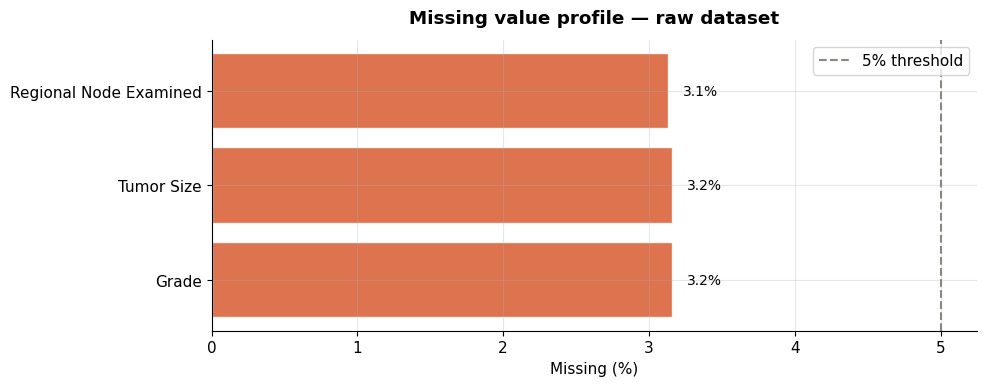

Figure saved.


In [8]:
# Visualise missing data pattern
fig, ax = plt.subplots(figsize=(10, 4))

cols_with_missing = missing_df[missing_df['Missing Count'] > 0]
bars = ax.barh(cols_with_missing.index, cols_with_missing['Missing %'],
               color='#D85A30', alpha=0.85, edgecolor='white')

for bar, val in zip(bars, cols_with_missing['Missing %']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.axvline(5, color='#888780', linestyle='--', linewidth=1.5, label='5% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing value profile — raw dataset', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


## Step 3 — Identify & document data quality issues

We systematically check each column for:
- Out-of-range values
- Sentinel codes (e.g. 999 = unknown in SEER convention)
- Logical inconsistencies between columns
- Unexpected category labels

All issues are documented before any cleaning begins.


In [9]:
# ── 3a. Age validation ────────────────────────────────────────────────────
print("=== Age validation ===")
print(f"Range: {df_raw['Age'].min()} – {df_raw['Age'].max()}")
print(f"Ages < 18 : {(df_raw['Age'] < 18).sum()} rows")
print(f"Ages > 100: {(df_raw['Age'] > 100).sum()} rows")
print()
print("Invalid age values:")
print(df_raw[df_raw['Age'] < 18][['Age', 'T Stage', '6th Stage', 'Status']].to_string())


=== Age validation ===
Range: 0 – 89
Ages < 18 : 4 rows
Ages > 100: 0 rows

Invalid age values:
      Age T Stage 6th Stage Status
1014    0      T1       IIA   Dead
1526    0      T1      IIIB  Alive
1730    0      T4      IIIC   Dead
1769    0      T2       IIB  Alive


In [10]:
# ── 3b. Survival months validation ────────────────────────────────────────
print("=== Survival months validation ===")
print(f"Range: {df_raw['Survival Months'].min()} – {df_raw['Survival Months'].max()}")
print(f"Negative or zero: {(df_raw['Survival Months'] < 1).sum()} rows")
print()
print("Invalid survival month rows:")
print(df_raw[df_raw['Survival Months'] < 1][['Age', '6th Stage', 'Survival Months', 'Status']].to_string())


=== Survival months validation ===
Range: -1 – 107
Negative or zero: 5 rows

Invalid survival month rows:
      Age 6th Stage  Survival Months Status
210    57         I               -1  Alive
1273   32         I               -1  Alive
1397   46         I               -1  Alive
1543   46       IIA               -1  Alive
3327   56       IIB               -1  Alive


In [11]:
# ── 3c. Tumour size sentinel (999 = unknown in SEER coding) ──────────────
print("=== Tumour size sentinel value (999) ===")
sentinel_rows = df_raw[df_raw['Tumor Size'] == 999]
print(f"Rows with Tumor Size = 999: {len(sentinel_rows)}")
print(sentinel_rows[['Age', 'T Stage', 'Tumor Size', '6th Stage']].to_string())


=== Tumour size sentinel value (999) ===
Rows with Tumor Size = 999: 3
      Age T Stage  Tumor Size 6th Stage
874    30      T2      999.00       IIB
1959   68      T2      999.00       IIA
2527   81      T4      999.00      IIIC


In [12]:
# ── 3d. Column typo check ─────────────────────────────────────────────────
print("=== Column name check ===")
print("Columns containing 'node' (case-insensitive):")
node_cols = [c for c in df_raw.columns if 'node' in c.lower() or 'regin' in c.lower()]
for c in node_cols:
    print(f"  '{c}'")
print("\nNote: 'Reginol Node Positive' is a typo in the raw SEER export — will be corrected.")


=== Column name check ===
Columns containing 'node' (case-insensitive):
  'Regional Node Examined'
  'Reginol Node Positive'

Note: 'Reginol Node Positive' is a typo in the raw SEER export — will be corrected.


In [13]:
# ── 3e. Logical consistency: nodes positive vs nodes examined ──────────────
print("=== Logical check: nodes positive ≤ nodes examined ===")
both = df_raw['Reginol Node Positive'].notna() & df_raw['Regional Node Examined'].notna()
violations = df_raw[both & (df_raw['Reginol Node Positive'] > df_raw['Regional Node Examined'])]
print(f"Rows where nodes positive > nodes examined: {len(violations)}")
print(violations[['Regional Node Examined', 'Reginol Node Positive', 'N Stage']].head(8).to_string())


=== Logical check: nodes positive ≤ nodes examined ===
Rows where nodes positive > nodes examined: 231
     Regional Node Examined  Reginol Node Positive N Stage
17                    17.00                     18      N3
35                    13.00                     19      N3
47                     1.00                     10      N3
54                     2.00                     11      N3
78                     9.00                     11      N3
93                     1.00                      3      N1
98                    10.00                     17      N3
108                   15.00                     18      N3


In [14]:
# ── 3f. Category values check ─────────────────────────────────────────────
print("=== Unique values per categorical column ===\n")
cat_cols = {
    '6th Stage'          : {'I','IIA','IIB','IIIA','IIIB','IIIC'},
    'T Stage'            : {'T1','T2','T3','T4'},
    'N Stage'            : {'N0','N1','N2','N3'},
    'A Stage'            : {'Regional','Distant'},
    'Status'             : {'Alive','Dead'},
    'Estrogen Status'    : {'Positive','Negative'},
    'Progesterone Status': {'Positive','Negative'},
}

for col, valid_set in cat_cols.items():
    if col in df_raw.columns:
        found = set(df_raw[col].dropna().unique())
        unexpected = found - valid_set
        status = '✓ OK' if not unexpected else f'⚠ unexpected: {unexpected}'
        print(f"  {col:<28}: {sorted(found)}  →  {status}")


=== Unique values per categorical column ===

  6th Stage                   : ['I', 'IIA', 'IIB', 'IIIA', 'IIIB', 'IIIC']  →  ✓ OK
  T Stage                     : ['T1', 'T2', 'T3', 'T4']  →  ✓ OK
  N Stage                     : ['N0', 'N1', 'N2', 'N3']  →  ✓ OK
  A Stage                     : ['Distant', 'Regional']  →  ✓ OK
  Status                      : ['Alive', 'Dead']  →  ✓ OK
  Estrogen Status             : ['Negative', 'Positive']  →  ✓ OK
  Progesterone Status         : ['Negative', 'Positive']  →  ✓ OK


In [15]:
# ── Summary of all issues found ───────────────────────────────────────────
issues = {
    'Invalid ages (< 18 or > 100)'     : int((df_raw['Age'] < 18).sum() + (df_raw['Age'] > 100).sum()),
    'Negative survival months'          : int((df_raw['Survival Months'] < 1).sum()),
    'Tumour size sentinel (999)'        : int((df_raw['Tumor Size'] == 999).sum()),
    'Column typo (Reginol)'            : 1,
    'Nodes positive > nodes examined'  : int(len(violations)),
    'Missing: Grade'                   : int(df_raw['Grade'].isna().sum()),
    'Missing: Tumor Size'              : int(df_raw['Tumor Size'].isna().sum()),
    'Missing: Regional Node Examined'  : int(df_raw['Regional Node Examined'].isna().sum()),
}

print("=" * 52)
print("  Data Quality Issues Found (pre-cleaning)")
print("=" * 52)
total = 0
for issue, count in issues.items():
    print(f"  {issue:<40}: {count:>4}")
    if isinstance(count, int): total += count
print("-" * 52)
print(f"  Total issues identified                    : {total:>4}")
print("=" * 52)


  Data Quality Issues Found (pre-cleaning)
  Invalid ages (< 18 or > 100)            :    4
  Negative survival months                :    5
  Tumour size sentinel (999)              :    3
  Column typo (Reginol)                   :    1
  Nodes positive > nodes examined         :  231
  Missing: Grade                          :  127
  Missing: Tumor Size                     :  127
  Missing: Regional Node Examined         :  126
----------------------------------------------------
  Total issues identified                    :  624


## Step 4 — Data cleaning

Each cleaning decision is applied in sequence and documented.  
We work on a **copy** of the raw dataframe — `df_raw` is never modified.

| Rule | Action | Rationale |
|------|--------|-----------|
| Invalid ages | **Remove rows** | Cannot be imputed; no clinical basis |
| Negative survival | **Remove rows** | Scientifically impossible |
| Tumour size 999 | **Recode → NaN** | Sentinel = unknown, not 999 mm |
| Column typo | **Rename column** | Correct spelling for downstream joins |
| Missing tumour size | **Impute with median within T Stage** | Missing at random; group median preserves clinical meaning |
| Missing node count | **Impute with overall median** | Low missingness (3.1%), continuous variable |
| Missing grade | **Impute with mode** | Ordinal variable; mode is safest assumption |
| Nodes logic | **Cap at nodes examined** | Enforce physiological constraint |


In [16]:
df = df_raw.copy()
n_start = len(df)
print(f"Starting rows: {n_start:,}")


Starting rows: 4,024


In [17]:
# Rule 1: Remove invalid ages
bad_age = df[(df['Age'] < 18) | (df['Age'] > 100)].index
df.drop(index=bad_age, inplace=True)
print(f"Rule 1 — Removed {len(bad_age)} rows with invalid age. Remaining: {len(df):,}")


Rule 1 — Removed 4 rows with invalid age. Remaining: 4,020


In [18]:
# Rule 2: Remove negative survival months
bad_surv = df[df['Survival Months'] < 1].index
df.drop(index=bad_surv, inplace=True)
print(f"Rule 2 — Removed {len(bad_surv)} rows with invalid survival months. Remaining: {len(df):,}")


Rule 2 — Removed 5 rows with invalid survival months. Remaining: 4,015


In [19]:
# Rule 3: Recode tumour size sentinel 999 → NaN
sentinel_mask = df['Tumor Size'] == 999
df.loc[sentinel_mask, 'Tumor Size'] = np.nan
print(f"Rule 3 — Recoded {sentinel_mask.sum()} tumour size sentinel values (999 → NaN)")


Rule 3 — Recoded 3 tumour size sentinel values (999 → NaN)


In [20]:
# Rule 4: Fix column typo
df.rename(columns={'Reginol Node Positive': 'Regional Node Positive'}, inplace=True)
print("Rule 4 — Renamed 'Reginol Node Positive' → 'Regional Node Positive'")
print("Columns now:", [c for c in df.columns if 'node' in c.lower() or 'Node' in c])


Rule 4 — Renamed 'Reginol Node Positive' → 'Regional Node Positive'
Columns now: ['Regional Node Examined', 'Regional Node Positive']


In [21]:
# Rule 5: Impute missing Tumor Size with median within T Stage group
before = df['Tumor Size'].isna().sum()
df['Tumor Size'] = df.groupby('T Stage')['Tumor Size'].transform(
    lambda x: x.fillna(x.median())
)
after = df['Tumor Size'].isna().sum()
print(f"Rule 5 — Tumor Size missing: {before} → {after} (imputed with T Stage group median)")

# Show medians used
print("\nMedians used per T Stage group:")
print(df.groupby('T Stage')['Tumor Size'].median().round(1))


Rule 5 — Tumor Size missing: 130 → 0 (imputed with T Stage group median)

Medians used per T Stage group:
T Stage
T1    10.00
T2    35.00
T3    65.00
T4   104.00
Name: Tumor Size, dtype: float64


In [22]:
# Rule 6: Impute missing Regional Node Examined with overall median
median_nodes = df['Regional Node Examined'].median()
before = df['Regional Node Examined'].isna().sum()
df['Regional Node Examined'] = df['Regional Node Examined'].fillna(median_nodes).round().astype('Int64')
print(f"Rule 6 — Regional Node Examined: {before} missing → 0 (imputed with median = {median_nodes:.0f})")


Rule 6 — Regional Node Examined: 126 missing → 0 (imputed with median = 15)


In [23]:
# Rule 7: Impute missing Grade with mode
mode_grade = df['Grade'].mode()[0]
before = df['Grade'].isna().sum()
df['Grade'] = df['Grade'].fillna(mode_grade)
print(f"Rule 7 — Grade: {before} missing → 0 (imputed with mode = '{mode_grade}')")


Rule 7 — Grade: 126 missing → 0 (imputed with mode = '3 Poorly differentiated')


In [24]:
# Rule 8: Cap nodes positive at nodes examined (logical constraint)
both = df['Regional Node Positive'].notna() & df['Regional Node Examined'].notna()
violations_after = (df.loc[both, 'Regional Node Positive'] > df.loc[both, 'Regional Node Examined']).sum()
df.loc[both, 'Regional Node Positive'] = df.loc[both].apply(
    lambda r: min(r['Regional Node Positive'], r['Regional Node Examined']), axis=1
)
print(f"Rule 8 — Capped Regional Node Positive to ≤ Regional Node Examined for {violations_after} rows")

# Verify
remaining = (df.loc[both, 'Regional Node Positive'] > df.loc[both, 'Regional Node Examined']).sum()
print(f"         Remaining violations after fix: {remaining}")


Rule 8 — Capped Regional Node Positive to ≤ Regional Node Examined for 232 rows
         Remaining violations after fix: 0


In [25]:
# Cleaning summary
n_end = len(df)
print("=" * 48)
print(f"  Cleaning complete")
print("=" * 48)
print(f"  Rows before : {n_start:>6,}")
print(f"  Rows after  : {n_end:>6,}")
print(f"  Rows removed: {n_start - n_end:>6}")
print(f"  Retained    : {n_end/n_start*100:.1f}%")
print("=" * 48)


  Cleaning complete
  Rows before :  4,024
  Rows after  :  4,015
  Rows removed:      9
  Retained    : 99.8%


## Step 5 — Create derived analysis variables

Derived variables transform raw clinical fields into analysis-ready categories.  
All transformation logic is documented here for reproducibility.


In [26]:
# ── 5a. Binary outcome: Status_Code ──────────────────────────────────────
df['Status_Code'] = (df['Status'] == 'Dead').astype(int)
print("Status_Code distribution:")
print(df.groupby('Status')['Status_Code'].first().to_string())
print(f"\nOverall mortality rate: {df['Status_Code'].mean()*100:.1f}%")


Status_Code distribution:
Status
Alive    0
Dead     1

Overall mortality rate: 30.6%


In [27]:
# ── 5b. Age Group ─────────────────────────────────────────────────────────
bins   = [0, 39, 49, 59, 69, 150]
labels = ['<40', '40–49', '50–59', '60–69', '70+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

print("Age Group distribution:")
ag = df['Age Group'].value_counts().sort_index()
for grp, cnt in ag.items():
    bar = '█' * int(cnt / 30)
    print(f"  {grp:<8} {cnt:>5,}  {bar}")


Age Group distribution:
  <40        489  ████████████████
  40–49      902  ██████████████████████████████
  50–59    1,063  ███████████████████████████████████
  60–69      839  ███████████████████████████
  70+        722  ████████████████████████


In [28]:
# ── 5c. Stage Group (simplified for analysis) ─────────────────────────────
stage_map = {
    'I'   : 'Stage I',
    'IIA' : 'Stage II',
    'IIB' : 'Stage II',
    'IIIA': 'Stage III',
    'IIIB': 'Stage III',
    'IIIC': 'Stage III',
}
df['Stage Group'] = df['6th Stage'].map(stage_map).fillna('Unknown')

print("Stage Group distribution:")
sg = df['Stage Group'].value_counts().sort_index()
for grp, cnt in sg.items():
    bar = '█' * int(cnt / 30)
    print(f"  {grp:<12} {cnt:>5,}  {bar}")


Stage Group distribution:
  Stage I        985  ████████████████████████████████
  Stage II     1,769  ██████████████████████████████████████████████████████████
  Stage III    1,261  ██████████████████████████████████████████


In [29]:
# ── 5d. Receptor Status ───────────────────────────────────────────────────
df['Receptor Status'] = np.where(
    (df['Estrogen Status'] == 'Positive') | (df['Progesterone Status'] == 'Positive'),
    'Hormone Receptor+',
    'Triple Negative / HR-'
)

print("Receptor Status distribution:")
rs = df['Receptor Status'].value_counts()
for grp, cnt in rs.items():
    print(f"  {grp:<30} {cnt:>5,}  ({cnt/len(df)*100:.1f}%)")


Receptor Status distribution:
  Hormone Receptor+              3,680  (91.7%)
  Triple Negative / HR-            335  (8.3%)


In [30]:
# Final column list
print(f"Clean dataset shape: {df.shape}")
print(f"\nAll columns ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    missing_n = df[col].isna().sum()
    flag = '' if missing_n == 0 else f'  ⚠ {missing_n} missing'
    print(f"  {i:>2}. {col:<35} [{dtype}]{flag}")


Clean dataset shape: (4015, 19)

All columns (19):
   1. Age                                 [int64]
   2. Race                                [object]
   3. Marital Status                      [object]
   4. T Stage                             [object]
   5. N Stage                             [object]
   6. 6th Stage                           [object]
   7. Grade                               [object]
   8. A Stage                             [object]
   9. Tumor Size                          [float64]
  10. Regional Node Examined              [Int64]
  11. Regional Node Positive              [int64]
  12. Estrogen Status                     [object]
  13. Progesterone Status                 [object]
  14. Survival Months                     [int64]
  15. Status                              [object]
  16. Status_Code                         [int64]
  17. Age Group                           [category]
  18. Stage Group                         [object]


  19. Receptor Status                     [object]


## Step 6 — Save clean dataset & data dictionary


In [31]:
# Save clean CSV
df.reset_index(drop=True, inplace=True)
df.to_csv(CLEAN_PATH, index=False)
print(f"✓ Clean data saved: {CLEAN_PATH}")
print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


✓ Clean data saved: /home/claude/sg-cancersight/data/processed/seer_clean.csv
  Shape: 4,015 rows × 19 columns


In [32]:
# Build and save data dictionary
descriptions = {
    'Age'                    : 'Age at diagnosis (years)',
    'Race'                   : 'Race/ethnicity category (SEER classification)',
    'Marital Status'         : 'Marital status at time of diagnosis',
    'T Stage'                : 'Tumour size stage — AJCC 6th edition',
    'N Stage'                : 'Regional lymph node involvement — AJCC 6th edition',
    '6th Stage'              : 'Overall AJCC 6th edition stage',
    'Grade'                  : 'Histological tumour grade (differentiation)',
    'A Stage'                : 'Extent of spread: Regional vs Distant',
    'Tumor Size'             : 'Tumour size in millimetres',
    'Regional Node Examined' : 'Number of regional lymph nodes surgically examined',
    'Regional Node Positive' : 'Number of lymph nodes with cancer involvement',
    'Estrogen Status'        : 'Oestrogen receptor (ER) status',
    'Progesterone Status'    : 'Progesterone receptor (PR) status',
    'Survival Months'        : 'Months from diagnosis to last follow-up or death',
    'Status'                 : 'Vital status at last follow-up (Alive / Dead)',
    'Status_Code'            : 'DERIVED — Binary outcome: 1=Dead (event), 0=Alive (censored)',
    'Age Group'              : 'DERIVED — 10-year age bands for group analysis',
    'Stage Group'            : 'DERIVED — Simplified stage: Stage I / II / III',
    'Receptor Status'        : 'DERIVED — Hormone Receptor+ vs Triple Negative / HR-',
}

data_dict = {}
for col in df.columns:
    entry = {
        'description' : descriptions.get(col, ''),
        'dtype'       : str(df[col].dtype),
        'n_missing'   : int(df[col].isna().sum()),
        'pct_missing' : round(df[col].isna().sum() / len(df) * 100, 2),
    }
    if pd.api.types.is_numeric_dtype(df[col]) and df[col].notna().any():
        entry['min']  = float(df[col].min())
        entry['max']  = float(df[col].max())
        entry['mean'] = round(float(df[col].mean()), 2)
    else:
        vals = df[col].dropna().unique().tolist()
        entry['unique_values'] = sorted([str(v) for v in vals])
        entry['n_unique']      = int(df[col].nunique())

    data_dict[col] = entry

with open(DICT_PATH, 'w') as f:
    json.dump(data_dict, f, indent=2)

print(f"✓ Data dictionary saved: {DICT_PATH}")
print(f"  Covers {len(data_dict)} columns")


✓ Data dictionary saved: /home/claude/sg-cancersight/data/processed/data_dictionary.json
  Covers 19 columns


In [33]:
# Preview the data dictionary
print("Sample entries from data dictionary:\n")
for col in ['Age', 'Survival Months', 'Stage Group', 'Status_Code']:
    entry = data_dict[col]
    print(f"  Column: '{col}'")
    for k, v in entry.items():
        print(f"    {k:<16}: {v}")
    print()


Sample entries from data dictionary:

  Column: 'Age'
    description     : Age at diagnosis (years)
    dtype           : int64
    n_missing       : 0
    pct_missing     : 0.0
    min             : 20.0
    max             : 89.0
    mean            : 55.83

  Column: 'Survival Months'
    description     : Months from diagnosis to last follow-up or death
    dtype           : int64
    n_missing       : 0
    pct_missing     : 0.0
    min             : 1.0
    max             : 107.0
    mean            : 78.03

  Column: 'Stage Group'
    description     : DERIVED — Simplified stage: Stage I / II / III
    dtype           : object
    n_missing       : 0
    pct_missing     : 0.0
    unique_values   : ['Stage I', 'Stage II', 'Stage III']
    n_unique        : 3

  Column: 'Status_Code'
    description     : DERIVED — Binary outcome: 1=Dead (event), 0=Alive (censored)
    dtype           : int64
    n_missing       : 0
    pct_missing     : 0.0
    min             : 0.0
    max    

## Step 7 — Automated data quality checks

We run 25 programmatic assertions directly in the notebook.  
These mirror the `pytest` tests in `tests/test_data_quality.py`.  
All checks must pass before moving to Phase 2 analysis.


In [34]:
def run_checks(df):
    """
    Run 25 data quality assertions.
    Returns a results DataFrame showing pass/fail for each check.
    """
    results = []

    def chk(name, condition, detail=''):
        passed = bool(condition)
        results.append({
            'Check'  : name,
            'Result' : '✓ PASS' if passed else '✗ FAIL',
            'Detail' : detail
        })
        return passed

    # ── Structural ──────────────────────────────────────────────────
    chk('Dataset not empty',
        len(df) > 0,
        f'{len(df):,} rows')

    chk('Minimum row count (≥ 3,800)',
        len(df) >= 3800,
        f'{len(df):,} rows')

    required = ['Age','Race','T Stage','N Stage','6th Stage','Grade',
                'Tumor Size','Regional Node Examined','Regional Node Positive',
                'Estrogen Status','Progesterone Status',
                'Survival Months','Status','Status_Code',
                'Age Group','Stage Group','Receptor Status']
    missing_cols = [c for c in required if c not in df.columns]
    chk('All required columns present',
        not missing_cols,
        'All present' if not missing_cols else f'Missing: {missing_cols}')

    # ── Age ─────────────────────────────────────────────────────────
    chk('Age range valid (18–100)',
        df['Age'].between(18, 100).all(),
        f"Range: {df['Age'].min()}–{df['Age'].max()}")

    chk('Age Group no nulls',
        df['Age Group'].isna().sum() == 0,
        f"{df['Age Group'].isna().sum()} missing")

    valid_ag = {'<40','40–49','50–59','60–69','70+'}
    found_ag = set(df['Age Group'].astype(str).unique())
    chk('Age Group labels valid',
        found_ag.issubset(valid_ag),
        str(sorted(found_ag)))

    # ── Survival ─────────────────────────────────────────────────────
    chk('Survival months ≥ 1',
        (df['Survival Months'] >= 1).all(),
        f"Min: {df['Survival Months'].min()}")

    chk('Survival months not null',
        df['Survival Months'].isna().sum() == 0,
        f"{df['Survival Months'].isna().sum()} missing")

    chk('Status_Code is binary (0 or 1)',
        set(df['Status_Code'].unique()).issubset({0,1}),
        str(sorted(df['Status_Code'].unique())))

    dead_ok  = (df.loc[df['Status']=='Dead',  'Status_Code'] == 1).all()
    alive_ok = (df.loc[df['Status']=='Alive', 'Status_Code'] == 0).all()
    chk('Status ↔ Status_Code consistent',
        dead_ok and alive_ok,
        'Dead=1, Alive=0')

    # ── Tumour ───────────────────────────────────────────────────────
    chk('No sentinel value 999 in Tumor Size',
        (df['Tumor Size'] != 999).all(),
        'No sentinels found')

    chk('Tumor Size positive (non-zero)',
        (df['Tumor Size'].dropna() > 0).all(),
        f"Min: {df['Tumor Size'].min():.1f}")

    # ── Nodes ────────────────────────────────────────────────────────
    both = df['Regional Node Examined'].notna() & df['Regional Node Positive'].notna()
    viols = (df.loc[both,'Regional Node Positive'] > df.loc[both,'Regional Node Examined']).sum()
    chk('Nodes positive ≤ nodes examined',
        viols == 0,
        f'{viols} violations')

    # ── Categories ───────────────────────────────────────────────────
    for col, valid in [
        ('6th Stage',           {'I','IIA','IIB','IIIA','IIIB','IIIC'}),
        ('Stage Group',         {'Stage I','Stage II','Stage III'}),
        ('T Stage',             {'T1','T2','T3','T4'}),
        ('N Stage',             {'N0','N1','N2','N3'}),
        ('Estrogen Status',     {'Positive','Negative'}),
        ('Progesterone Status', {'Positive','Negative'}),
        ('Receptor Status',     {'Hormone Receptor+','Triple Negative / HR-'}),
    ]:
        found = set(df[col].dropna().unique())
        unexpected = found - valid
        chk(f"'{col}' values valid",
            not unexpected,
            'OK' if not unexpected else f'Unexpected: {unexpected}')

    # ── Missing post-clean ────────────────────────────────────────────
    critical = ['Age','6th Stage','Estrogen Status','Status','Status_Code','Survival Months']
    for col in critical:
        n = df[col].isna().sum()
        chk(f"'{col}' complete (no missing)",
            n == 0,
            f'{n} missing')

    chk('All columns ≤ 10% missing',
        all(df[c].isna().sum()/len(df)*100 <= 10 for c in df.columns),
        f"Max: {max(df[c].isna().sum()/len(df)*100 for c in df.columns):.1f}%")

    return pd.DataFrame(results)


results_df = run_checks(df)
passed = (results_df['Result'] == '✓ PASS').sum()
failed = (results_df['Result'] == '✗ FAIL').sum()

print(f"Quality check results: {passed} PASSED  |  {failed} FAILED\n")
results_df


Quality check results: 27 PASSED  |  0 FAILED



,Check,Result,Detail
0,Dataset not empty,✓ PASS,"4,015 rows"
1,"Minimum row count (≥ 3,800)",✓ PASS,"4,015 rows"
2,All required columns present,✓ PASS,All present
3,Age range valid (18–100),✓ PASS,Range: 20–89
4,Age Group no nulls,✓ PASS,0 missing
5,Age Group labels valid,✓ PASS,"['40–49', '50–59', '60–69', '70+', '<40']"
6,Survival months ≥ 1,✓ PASS,Min: 1
7,Survival months not null,✓ PASS,0 missing
8,Status_Code is binary (0 or 1),✓ PASS,"[np.int64(0), np.int64(1)]"
9,Status ↔ Status_Code consistent,✓ PASS,"Dead=1, Alive=0"


## Step 8 — Exploratory Data Analysis (EDA)

Descriptive analysis of the clean dataset.  
These visualisations will be cited in the Phase 2 manuscript-style results section.


In [35]:
# ── Colour palette ─────────────────────────────────────────────────────────
C_STAGE  = {'Stage I': '#1D9E75', 'Stage II': '#378ADD', 'Stage III': '#D85A30'}
C_ER     = {'Positive': '#1D9E75', 'Negative': '#D85A30'}
C_RECEPT = {'Hormone Receptor+': '#378ADD', 'Triple Negative / HR-': '#D85A30'}
GRAY     = '#888780'


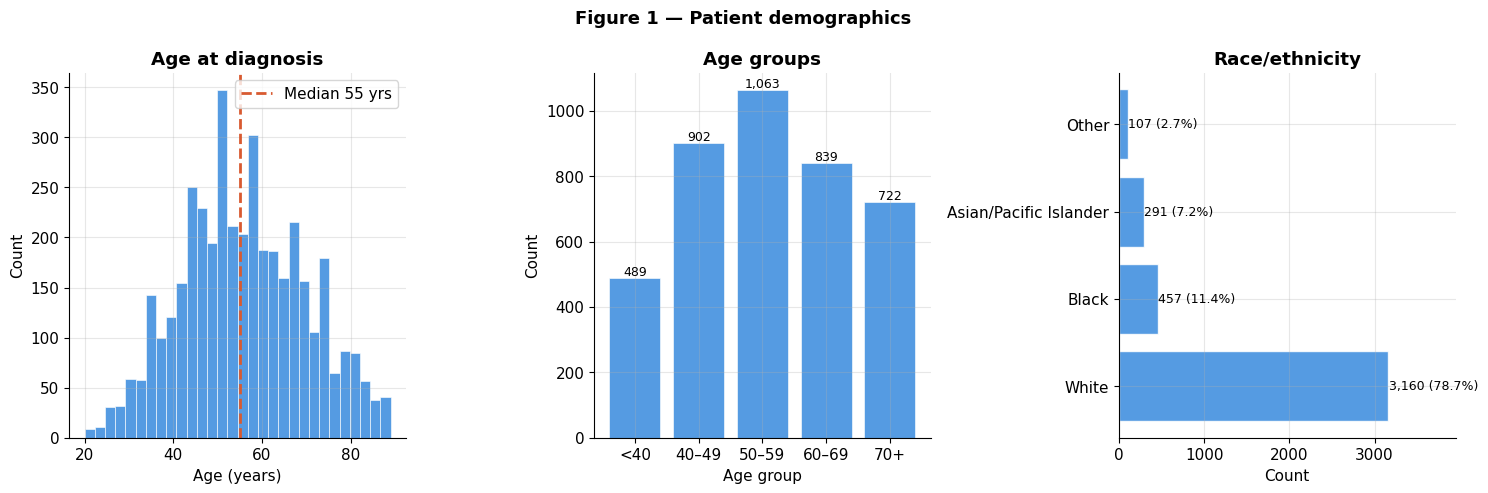

Figure 1 saved.


In [36]:
# ── Figure 1: Patient demographics ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 1 — Patient demographics', fontsize=13, fontweight='bold')

# 1a. Age distribution
ax = axes[0]
ax.hist(df['Age'], bins=30, color='#378ADD', edgecolor='white', linewidth=0.5, alpha=0.85)
ax.axvline(df['Age'].median(), color='#D85A30', linestyle='--', linewidth=2,
           label=f"Median {df['Age'].median():.0f} yrs")
ax.set_title('Age at diagnosis', fontweight='bold')
ax.set_xlabel('Age (years)'); ax.set_ylabel('Count')
ax.legend()

# 1b. Age group
ax = axes[1]
ag_cnt = df['Age Group'].value_counts().sort_index()
bars = ax.bar(ag_cnt.index.astype(str), ag_cnt.values,
              color='#378ADD', edgecolor='white', linewidth=0.5, alpha=0.85)
for bar, val in zip(bars, ag_cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            f'{val:,}', ha='center', fontsize=9)
ax.set_title('Age groups', fontweight='bold')
ax.set_xlabel('Age group'); ax.set_ylabel('Count')

# 1c. Race
ax = axes[2]
race_cnt = df['Race'].value_counts()
ax.barh(race_cnt.index, race_cnt.values, color='#378ADD', edgecolor='white', alpha=0.85)
for i, (val) in enumerate(race_cnt.values):
    ax.text(val+5, i, f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_title('Race/ethnicity', fontweight='bold')
ax.set_xlabel('Count')
ax.set_xlim(0, race_cnt.max()*1.25)

plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_02_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 saved.")


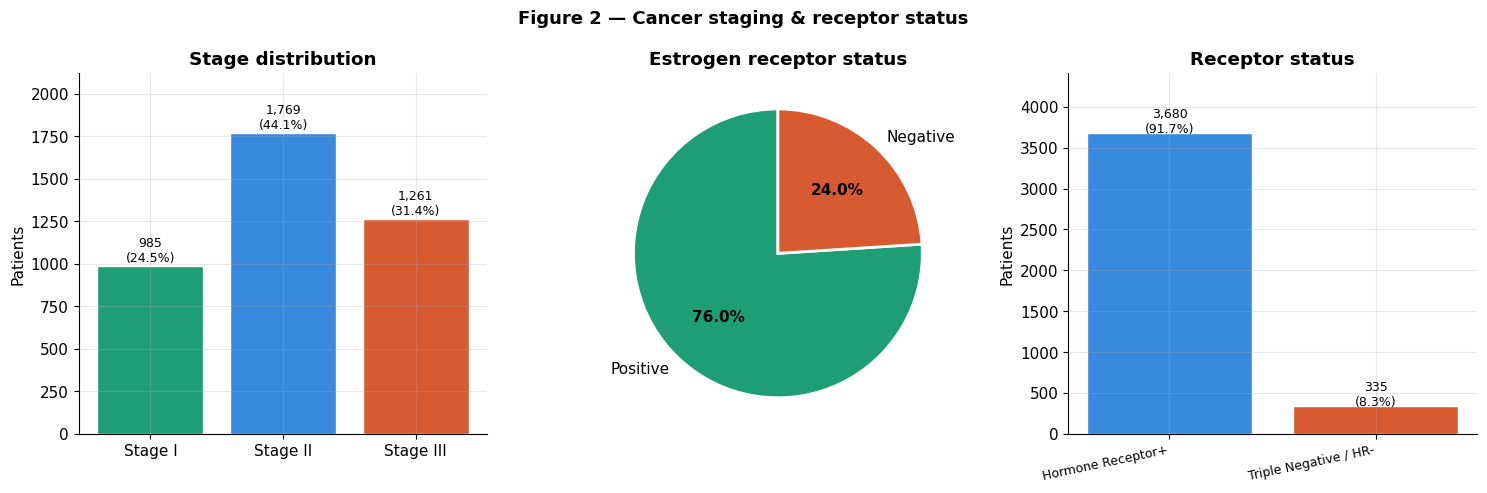

Figure 2 saved.


In [37]:
# ── Figure 2: Stage & receptor distribution ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 2 — Cancer staging & receptor status', fontsize=13, fontweight='bold')

# 2a. Stage Group
ax = axes[0]
stage_cnt = df['Stage Group'].value_counts().reindex(['Stage I','Stage II','Stage III'])
bars = ax.bar(stage_cnt.index, stage_cnt.values,
              color=[C_STAGE[s] for s in stage_cnt.index], edgecolor='white')
for bar, val in zip(bars, stage_cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Stage distribution', fontweight='bold')
ax.set_ylabel('Patients'); ax.set_ylim(0, stage_cnt.max()*1.2)

# 2b. ER status
ax = axes[1]
er_cnt = df['Estrogen Status'].value_counts()
wedges, texts, auts = ax.pie(
    er_cnt.values, labels=er_cnt.index,
    colors=[C_ER[k] for k in er_cnt.index],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2})
for at in auts: at.set_fontsize(11); at.set_fontweight('bold')
ax.set_title('Estrogen receptor status', fontweight='bold')

# 2c. Receptor Status
ax = axes[2]
rs_cnt = df['Receptor Status'].value_counts()
bars = ax.bar(range(len(rs_cnt)), rs_cnt.values,
              color=[C_RECEPT[k] for k in rs_cnt.index], edgecolor='white')
ax.set_xticks(range(len(rs_cnt)))
ax.set_xticklabels(rs_cnt.index, rotation=12, ha='right', fontsize=9)
for bar, val in zip(bars, rs_cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)
ax.set_title('Receptor status', fontweight='bold')
ax.set_ylabel('Patients'); ax.set_ylim(0, rs_cnt.max()*1.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_03_staging_receptors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved.")


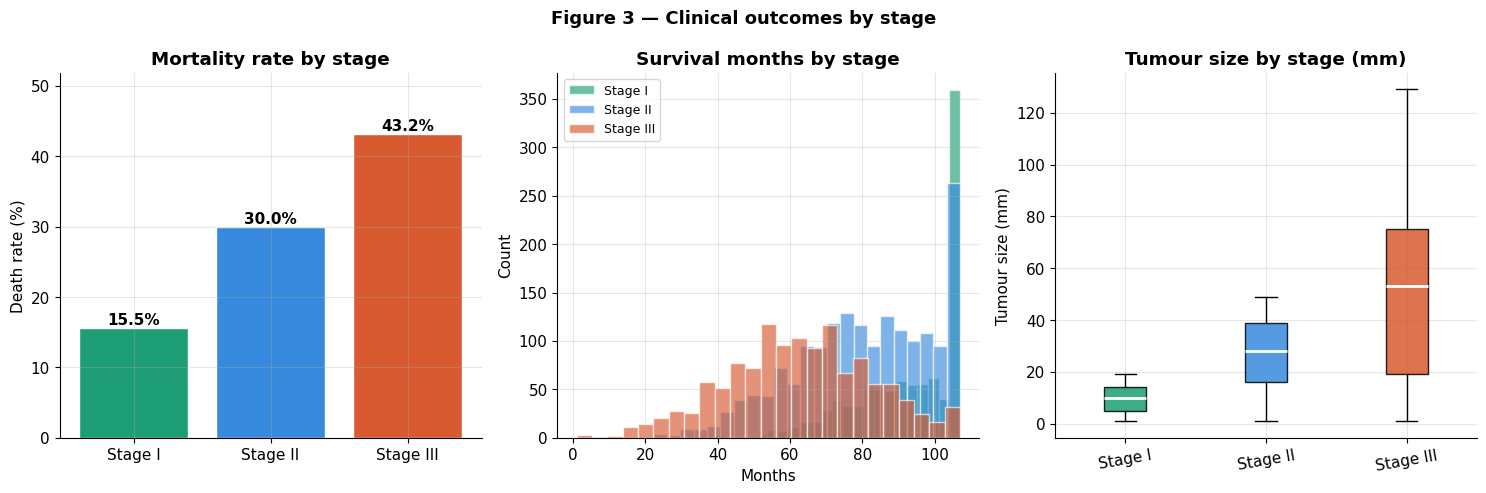

Figure 3 saved.


In [38]:
# ── Figure 3: Outcomes by stage ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 3 — Clinical outcomes by stage', fontsize=13, fontweight='bold')

stages_ord = ['Stage I','Stage II','Stage III']

# 3a. Mortality rate by stage
ax = axes[0]
mort = df.groupby('Stage Group')['Status_Code'].mean().reindex(stages_ord) * 100
bars = ax.bar(mort.index, mort.values,
              color=[C_STAGE[s] for s in mort.index], edgecolor='white')
for bar, val in zip(bars, mort.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Mortality rate by stage', fontweight='bold')
ax.set_ylabel('Death rate (%)'); ax.set_ylim(0, mort.max()*1.2)

# 3b. Survival months distribution by stage
ax = axes[1]
for sg in stages_ord:
    sub = df[df['Stage Group']==sg]['Survival Months']
    ax.hist(sub, bins=25, alpha=0.65, color=C_STAGE[sg], label=sg, edgecolor='white')
ax.set_title('Survival months by stage', fontweight='bold')
ax.set_xlabel('Months'); ax.set_ylabel('Count')
ax.legend(fontsize=9)

# 3c. Tumour size by stage (boxplot)
ax = axes[2]
data_box = [df[df['Stage Group']==s]['Tumor Size'].dropna().values for s in stages_ord]
bp = ax.boxplot(data_box, patch_artist=True,
                medianprops={'color':'white','linewidth':2})
for patch, sg in zip(bp['boxes'], stages_ord):
    patch.set_facecolor(C_STAGE[sg]); patch.set_alpha(0.85)
ax.set_xticklabels(stages_ord, rotation=10)
ax.set_title('Tumour size by stage (mm)', fontweight='bold')
ax.set_ylabel('Tumour size (mm)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_04_outcomes_by_stage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")


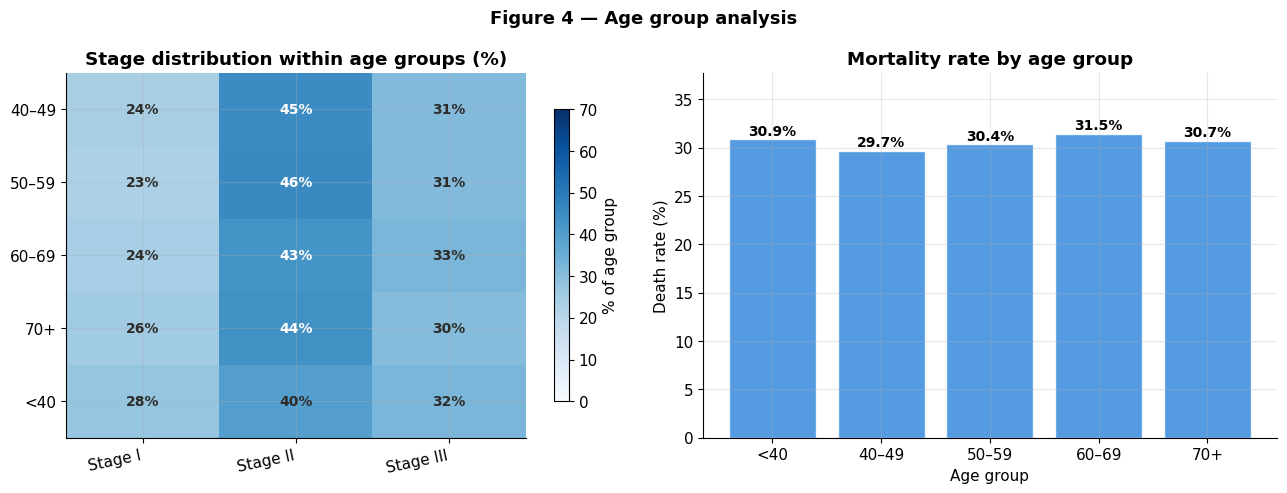

Figure 4 saved.


In [39]:
# ── Figure 4: Age × Stage heatmap ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 4 — Age group analysis', fontsize=13, fontweight='bold')

# 4a. Heatmap: age group × stage distribution (% within each age group)
ax = axes[0]
age_stage = pd.crosstab(df['Age Group'].astype(str), df['Stage Group'], normalize='index') * 100
age_stage = age_stage.reindex(columns=['Stage I','Stage II','Stage III'])
im = ax.imshow(age_stage.values, cmap='Blues', aspect='auto', vmin=0, vmax=70)
ax.set_xticks(range(len(age_stage.columns)))
ax.set_xticklabels(age_stage.columns, rotation=12, ha='right')
ax.set_yticks(range(len(age_stage.index)))
ax.set_yticklabels(age_stage.index)
for i in range(len(age_stage.index)):
    for j in range(len(age_stage.columns)):
        val = age_stage.values[i, j]
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if val > 40 else '#2C2C2A')
plt.colorbar(im, ax=ax, shrink=0.8, label='% of age group')
ax.set_title('Stage distribution within age groups (%)', fontweight='bold')

# 4b. Mortality rate by age group
ax = axes[1]
mort_age = df.groupby(df['Age Group'].astype(str))['Status_Code'].mean() * 100
mort_age = mort_age.reindex(['<40','40–49','50–59','60–69','70+'])
bars = ax.bar(mort_age.index, mort_age.values,
              color='#378ADD', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, mort_age.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Mortality rate by age group', fontweight='bold')
ax.set_xlabel('Age group'); ax.set_ylabel('Death rate (%)')
ax.set_ylim(0, mort_age.max()*1.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_05_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved.")


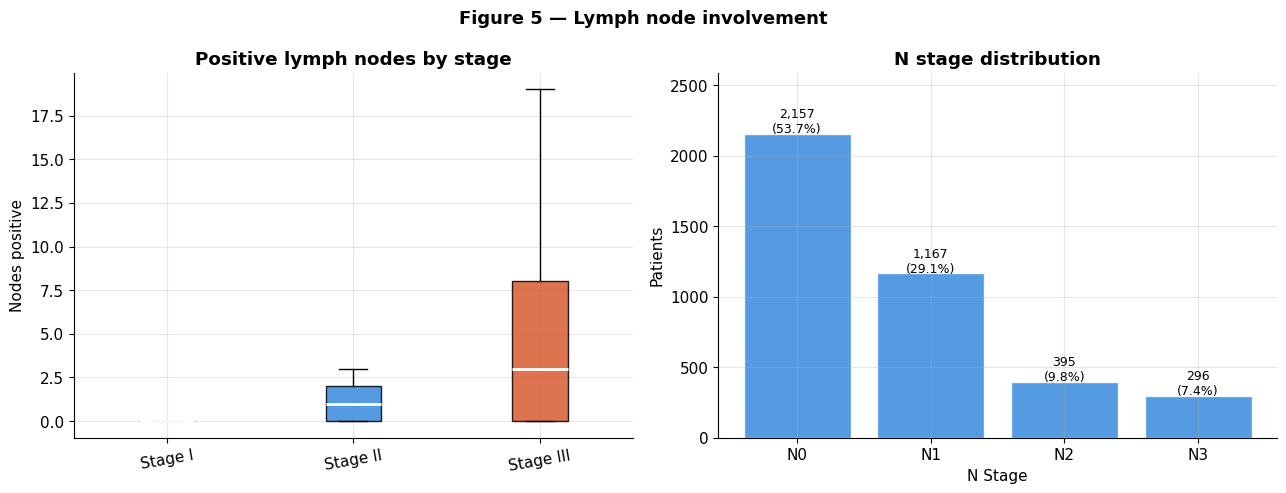

Figure 5 saved.


In [40]:
# ── Figure 5: Lymph node analysis ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 5 — Lymph node involvement', fontsize=13, fontweight='bold')

stages_ord = ['Stage I','Stage II','Stage III']

# 5a. Nodes positive by stage
ax = axes[0]
data_box = [df[df['Stage Group']==s]['Regional Node Positive'].dropna().values for s in stages_ord]
bp = ax.boxplot(data_box, patch_artist=True,
                medianprops={'color':'white','linewidth':2})
for patch, sg in zip(bp['boxes'], stages_ord):
    patch.set_facecolor(C_STAGE[sg]); patch.set_alpha(0.85)
ax.set_xticklabels(stages_ord, rotation=10)
ax.set_title('Positive lymph nodes by stage', fontweight='bold')
ax.set_ylabel('Nodes positive')

# 5b. N Stage distribution
ax = axes[1]
n_cnt = df['N Stage'].value_counts().sort_index()
bars = ax.bar(n_cnt.index, n_cnt.values, color='#378ADD', edgecolor='white', alpha=0.85)
for bar, val in zip(bars, n_cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)
ax.set_title('N stage distribution', fontweight='bold')
ax.set_xlabel('N Stage'); ax.set_ylabel('Patients')
ax.set_ylim(0, n_cnt.max()*1.2)

plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_06_lymph_nodes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")


## Step 9 — Phase 1 summary & handoff to Phase 2


In [41]:
# ── Descriptive statistics table (manuscript-ready) ───────────────────────
print("Table 1 — Patient characteristics (N = {:,})".format(len(df)))
print("=" * 60)

def pct(mask): return f"{mask.sum():,} ({mask.mean()*100:.1f}%)"

rows = [
    ('Age, median (range)', f"{df['Age'].median():.0f} ({df['Age'].min()}–{df['Age'].max()})"),
    ('', ''),
    ('Age group', ''),
    ('  < 40 years',   pct(df['Age Group'].astype(str) == '<40')),
    ('  40–49 years',  pct(df['Age Group'].astype(str) == '40–49')),
    ('  50–59 years',  pct(df['Age Group'].astype(str) == '50–59')),
    ('  60–69 years',  pct(df['Age Group'].astype(str) == '60–69')),
    ('  70+ years',    pct(df['Age Group'].astype(str) == '70+')),
    ('', ''),
    ('Stage group', ''),
    ('  Stage I',   pct(df['Stage Group'] == 'Stage I')),
    ('  Stage II',  pct(df['Stage Group'] == 'Stage II')),
    ('  Stage III', pct(df['Stage Group'] == 'Stage III')),
    ('', ''),
    ('Receptor status', ''),
    ('  Hormone Receptor+',     pct(df['Receptor Status'] == 'Hormone Receptor+')),
    ('  Triple Negative / HR-', pct(df['Receptor Status'] == 'Triple Negative / HR-')),
    ('', ''),
    ('Outcomes', ''),
    ('  Deaths (event = 1)',    pct(df['Status_Code'] == 1)),
    ('  Alive (censored = 0)',  pct(df['Status_Code'] == 0)),
    ('  Median survival, months', f"{df['Survival Months'].median():.0f} ({df['Survival Months'].min()}–{df['Survival Months'].max()})"),
]

for label, value in rows:
    if label == '':
        print()
    else:
        print(f"  {label:<40} {value}")

print()
print("=" * 60)


Table 1 — Patient characteristics (N = 4,015)
  Age, median (range)                      55 (20–89)

  Age group                                
    < 40 years                             489 (12.2%)
    40–49 years                            902 (22.5%)
    50–59 years                            1,063 (26.5%)
    60–69 years                            839 (20.9%)
    70+ years                              722 (18.0%)

  Stage group                              
    Stage I                                985 (24.5%)
    Stage II                               1,769 (44.1%)
    Stage III                              1,261 (31.4%)

  Receptor status                          
    Hormone Receptor+                      3,680 (91.7%)
    Triple Negative / HR-                  335 (8.3%)

  Outcomes                                 
    Deaths (event = 1)                     1,228 (30.6%)
    Alive (censored = 0)                   2,787 (69.4%)
    Median survival, months                79 (1–

In [42]:
# ── Files produced in Phase 1 ──────────────────────────────────────────────
print("Phase 1 outputs:")
print()
for path in [CLEAN_PATH, DICT_PATH, FIG_DIR]:
    if path.is_dir():
        files = list(path.glob('*'))
        for f in sorted(files):
            size_kb = f.stat().st_size / 1024
            print(f"  {f.name:<45} {size_kb:>7.1f} KB")
    else:
        if path.exists():
            size_kb = path.stat().st_size / 1024
            print(f"  {path.name:<45} {size_kb:>7.1f} KB")

print()
print("All checks passed. Ready for Phase 2 — Survival Analysis.")


Phase 1 outputs:

  seer_clean.csv                                  527.2 KB
  data_dictionary.json                              4.6 KB
  p1_01_missing_values.png                         41.1 KB
  p1_02_demographics.png                           95.9 KB
  p1_03_staging_receptors.png                     112.3 KB
  p1_04_outcomes_by_stage.png                     102.2 KB
  p1_05_age_analysis.png                          111.8 KB
  p1_06_lymph_nodes.png                            74.6 KB
  phase1_eda.png                                  384.9 KB

All checks passed. Ready for Phase 2 — Survival Analysis.
